In [1]:
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install seaborn
!pip install scikit-learn
!pip install yfinance

(ANALISE TECNICA)

Dado a crise do petroleo pela guerra entre IRÂ e EUA, devido a escalado pelo fechamento da ponta Ormuz onde aproximadamente 20% do petroleo naufraga para a distribuição, O preço do petróleo subiu significativamente 3%, com previsões de atingir $200 por barril, afetando o transporte de petróleo da Arábia Saudita, Catar e Kuwai, usamos o ETF "USO" dado sua importancia no mercado de contrato futuro ao petroleo americano, sua performance é importante para o cenario e previsibilidade do petroleo no mundo, apliquei modelos como FIBONNACI, MACD, BANDA DE BORLLINGER, RSI.


In [2]:
import matplotlib.pyplot as plt
import yfinance as yf


In [26]:
from numpy import matrix_transpose
def calcular_fibonacci(preco):
  # ENCONTRAR MAXIMO E MINIMO
  max_p = data[preco].max()
  min_p = data[preco].min()
  rango = max_p - min_p

  #calcular nivel
  nivel={
      "23.6": max_p - (rango *0.236),
      "38.2": max_p - (rango *0.382),
      "50": max_p - (rango *0.500),
      "61.8": max_p - (rango *0.618),
      "78.6": max_p - (rango *0.786),
      "100": max_p - (rango *1.000)
  }
  return nivel, max_p, min_p, rango

In [4]:
data=yf.download('USO', period='6mo', interval='1d')
fb, max_p, min_p, avg_p =calcular_fibonacci('Close')



/tmp/ipykernel_205/1665553140.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('USO', period='6mo', interval='1d')
[*********************100%***********************]  1 of 1 completed


In [5]:
data

Price,Close,High,Low,Open,Volume
Ticker,USO,USO,USO,USO,USO
Date,,,,,
2025-09-15,74.230003,74.680000,73.970001,74.260002,3985500
2025-09-16,75.669998,75.860001,74.800003,75.080002,5063900
2025-09-17,74.970001,75.699997,74.669998,75.410004,4020200
2025-09-18,74.690002,75.660004,74.279999,75.120003,4176200
2025-09-19,73.519997,74.480003,73.330002,73.949997,5958100
...,...,...,...,...,...
2026-03-09,104.330002,124.070000,98.470001,119.419998,143771900
2026-03-10,105.860001,107.559998,94.230003,107.129997,135401400


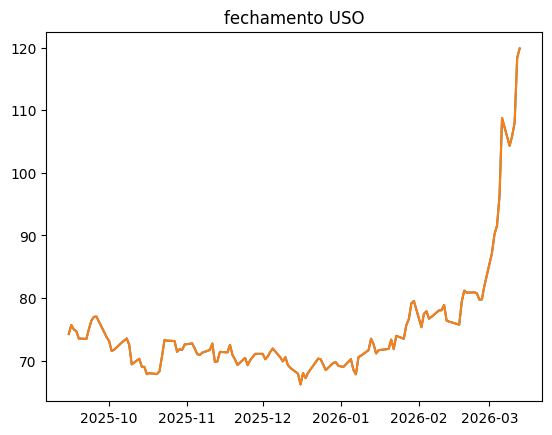

In [6]:
plt.plot(data['Close'])
plt.plot(data.index, data['Close'])
plt.plot
plt.title('fechamento USO')
plt.show()

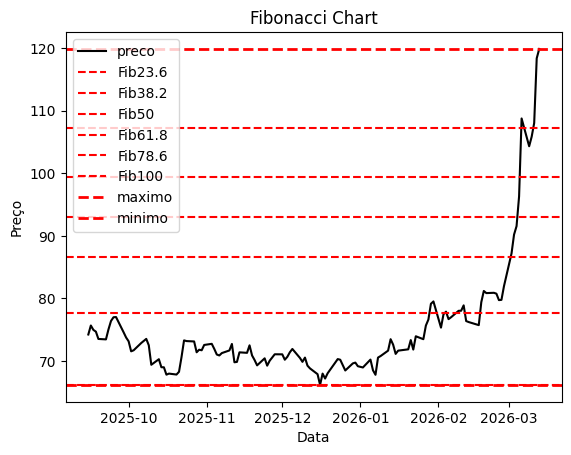

In [7]:
plt.plot(data['Close'], label='preco', color='black')

for nivel, preco in fb.items():
  # Extract the scalar value from the 'preco' Series
  plt.axhline(y=preco.item(), color='red', linestyle='--', label=f"Fib{nivel}")

# Extract the scalar values from max_p and min_p Series
plt.axhline(max_p.item(), color='red', linestyle='--', linewidth=2, label="maximo")
plt.axhline(min_p.item(), color='red', linestyle='--', linewidth=2, label="minimo")
plt.title('Fibonacci Chart')
plt.xlabel('Data')
plt.ylabel('Preço')
plt.legend()
plt.show()

In [8]:
import pandas as pd

def calular_bollinger(precos, periodo=20, desvio_padrao=2):
  media_movel = precos.rolling(window=periodo).mean()
  desvio = precos.rolling(window=periodo).std()
  superior = media_movel + (desvio_padrao * desvio)
  inferior = media_movel - (desvio_padrao * desvio)
  return media_movel, superior, inferior


In [9]:
data=yf.download('UKOIL', period='6mo')
sup, media, inf = calular_bollinger(data['Close'])


/tmp/ipykernel_205/19121904.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('UKOIL', period='6mo')
ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: UKOIL"}}}
[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['UKOIL']: YFPricesMissingError('possibly delisted; no price data found  (period=6mo) (Yahoo error = "No data found, symbol may be delisted")')


/tmp/ipykernel_205/530017037.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('USO', period='6mo')
[*********************100%***********************]  1 of 1 completed


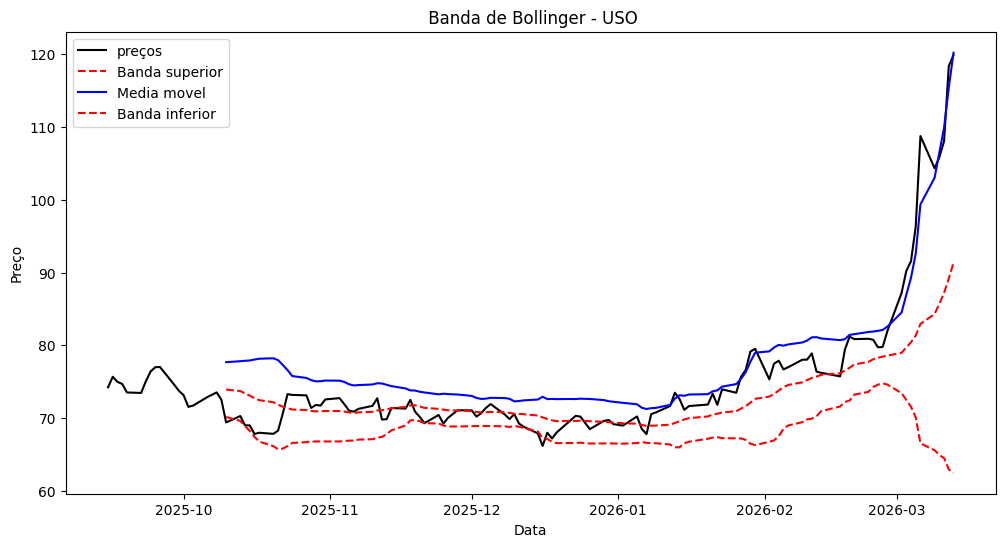

In [10]:
from matplotlib import lines
data=yf.download('USO', period='6mo')
sup, media, inf = calular_bollinger(data['Close'])

plt.figure(figsize=(12,6))
plt.plot(data['Close'], label="preços", color='black')
plt.plot(sup, label="Banda superior", color='red', linestyle='--')
plt.plot(media, label="Media movel", color='blue')
plt.plot(inf, label="Banda inferior", color='red', linestyle='--')
plt.title(" Banda de Bollinger - USO")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.show()

In [11]:

import numpy as np

def calcular_rsi(preco, period=14):
  delta=preco.diff()
  ganancia=delta.where(delta > 0,0)
  perdida=-delta.where(delta < 0,0)

  avg_ganancia=ganancia.rolling(window=period, min_periods=1).mean()
  avg_perdida=perdida.rolling(window=period, min_periods=1).mean()

  rs=avg_ganancia/avg_perdida
  rsi=100-(100/(1+rs))
  return rsi.dropna()


/tmp/ipykernel_205/1931627110.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download("USO", period="6mo")
[*********************100%***********************]  1 of 1 completed


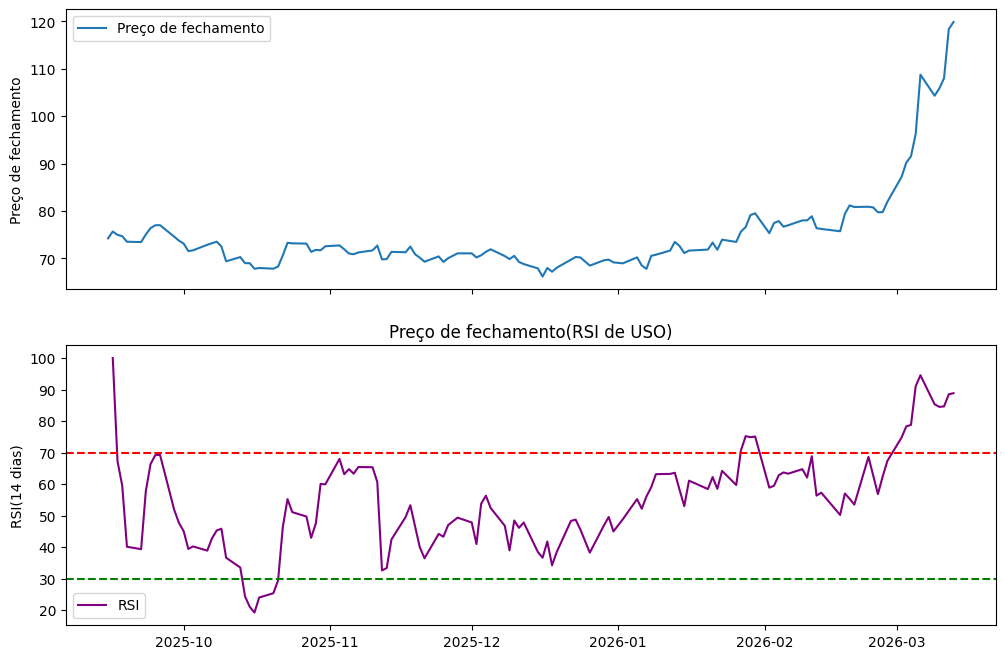

In [12]:
data=yf.download("USO", period="6mo")

rsi= calcular_rsi(data['Close'])

#Graficoo
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 8))

#preços
ax1.plot(data.index, data['Close'], label='Preço de fechamento')
ax1.set_ylabel('Preço de fechamento')

#RSI
ax2.plot(rsi.index, rsi, label='RSI', color='purple') # Corrected line: use rsi.index for alignment
ax2.axhline(y=70, color='red', linestyle='--')
ax2.axhline(y=30, color='green', linestyle='--')
ax2.set_ylabel('RSI(14 dias)')

#Etiquetas
ax1.legend()
ax2.legend()


plt.title('Preço de fechamento(RSI de USO)')
plt.show()

In [13]:
# METODO MACD


def calcular_macd(precos, rapido=12, lento=26, senal=9):
  ema_rapido=precos.ewm(span=rapido).mean()
  ema_lento=precos.ewm(span=lento).mean()

  macd=ema_rapido-ema_lento

  # Renamed 'signal_line' to avoid conflict and make histograma reachable
  signal_line=macd.ewm(span=senal).mean()
  histograma=macd-signal_line

  return macd, signal_line, histograma

# Sample data to resolve NameError: name 'precos' is not defined
# In a real scenario, 'precos' would come from your financial data, e.g., df['Close']
precos = pd.Series(np.random.rand(100) * 100 + 50, name='Close')

#usar
macd, signal_line, histograma=calcular_macd(precos)

print("MACD Head:\n", macd.head())
print("Signal Line Head:\n", signal_line.head())
print("Histograma Head:\n", histograma.head())



MACD Head:
 0    0.000000
1    0.005966
2    1.142872
3    0.623362
4   -0.789977
Name: Close, dtype: float64
Signal Line Head:
 0    0.000000
1    0.003315
2    0.470347
3    0.522181
4    0.131844
Name: Close, dtype: float64
Histograma Head:
 0    0.000000
1    0.002652
2    0.672526
3    0.101181
4   -0.921821
Name: Close, dtype: float64


/tmp/ipykernel_205/2221381947.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download('USO', period="6mo")
[*********************100%***********************]  1 of 1 completed


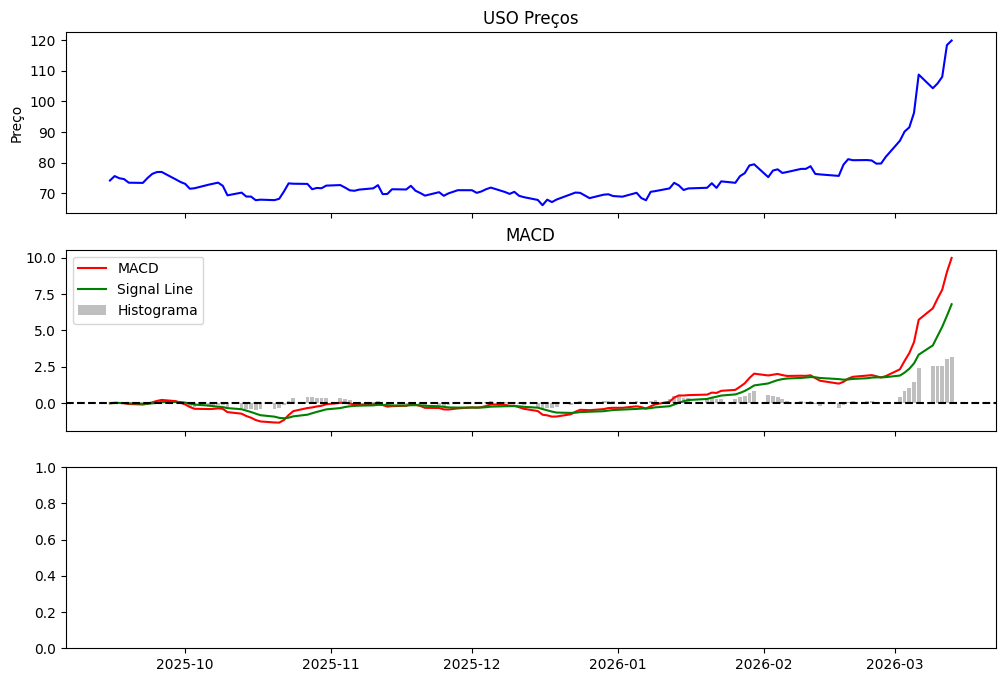

In [14]:
data=yf.download('USO', period="6mo")

#calcular MACD
macd, signal_line, histograma=calcular_macd(data['Close'])

#grafico
fig, (ax1, ax2, ax3)=plt.subplots(3, 1, sharex=True, figsize=(12,8))
#precos
ax1.plot(data.index, data['Close'], label='Preço', color='blue')
ax1.set_title('USO Preços') # Corrected from ax1.title()
ax1.set_ylabel('Preço')


# MACD
ax2.plot(data.index, macd, label='MACD', color='red')
ax2.plot(data.index, signal_line, label='Signal Line', color='green')
# Pass the 'USO' column from histograma as a Series
ax2.bar(data.index, histograma['USO'], label='Histograma', color='gray', alpha=0.5)
ax2.axhline(0, color='BLACK', linestyle='--')
ax2.legend()
ax2.set_title('MACD') # Corrected from ax2.title()
plt.show()

In [15]:
import pandas as pd
import yfinance as yf

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

#descarregar dados
data = yf.download('USO', period='3y')
df = pd.DataFrame(data)



/tmp/ipykernel_205/884803268.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('USO', period='3y')
[*********************100%***********************]  1 of 1 completed


ADF Statistic: -0.27064577439180587
p-value: 0.9295601043184019


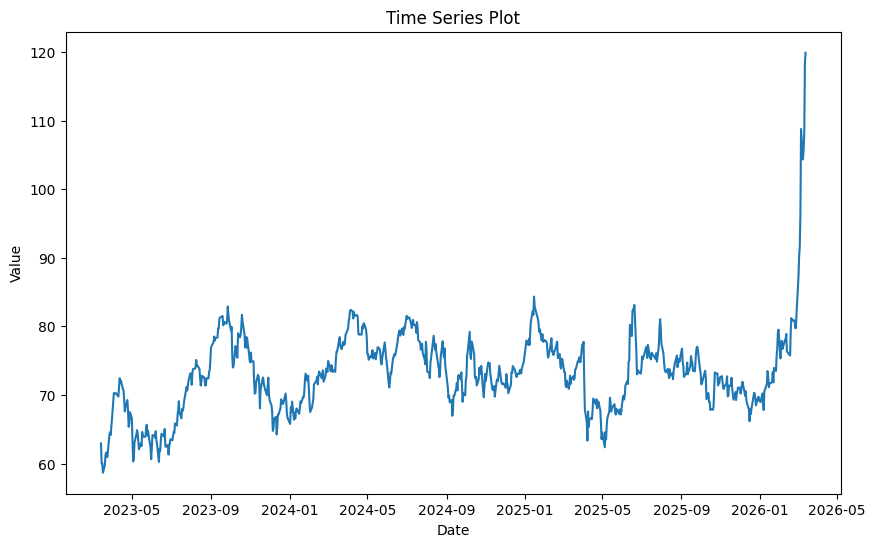

In [16]:
adf_result= adfuller(df['Close'].dropna())
print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')


plt.figure(figsize=(10, 6))
plt.plot(df['Close'])
plt.title('Time Series Plot')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()